In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

In [3]:
nav_df = pd.read_csv("../data/raw/02_nav_history.csv")
txn_df = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("NAV Shape:", nav_df.shape)
print("Transactions Shape:", txn_df.shape)
print("Portfolio Shape:", portfolio_df.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Portfolio Shape: (322, 8)


In [4]:
nav_df.columns.tolist()

['amfi_code', 'date', 'nav']

In [5]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df = nav_df.sort_values(['amfi_code', 'date'])

nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
    .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [7]:
var_cvar = []

for fund in nav_df['amfi_code'].unique():

    returns = nav_df[
        nav_df['amfi_code'] == fund
    ]['daily_return'].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(returns, 5)

        cvar_95 = returns[
            returns <= var_95
        ].mean()

        var_cvar.append([
            fund,
            var_95,
            cvar_95
        ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
print(var_cvar_df.shape)
var_cvar_df.head()

(40, 3)


,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [10]:
var_cvar_df.describe()

,amfi_code,VaR_95,CVaR_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [11]:
sharpe_df = pd.read_csv("../data/processed/sharpe_ratio.csv")

print(sharpe_df.shape)
sharpe_df.head()

(40, 4)


,amfi_code,annual_return,annual_volatility,sharpe_ratio
0,100016,3.57,14.55,-0.202
1,100025,4.29,3.91,-0.567
2,100033,27.21,18.94,1.094
3,101206,21.46,14.57,1.027
4,101207,10.70,25.80,0.163


In [12]:
sharpe_df.sort_values(
    by=sharpe_df.columns[-1],
    ascending=False
).head(10)

,amfi_code,annual_return,annual_volatility,sharpe_ratio
34,148567,27.06,14.19,1.448
30,120843,27.26,15.89,1.307
36,148569,28.33,17.67,1.235
19,119551,23.10,13.74,1.208
25,120505,29.27,19.29,1.180
38,149323,26.59,17.75,1.132
2,100033,27.21,18.94,1.094
9,118632,21.80,14.15,1.082
3,101206,21.46,14.57,1.027
24,120504,21.24,14.36,1.027


In [13]:
print(sharpe_df.columns.tolist())

['amfi_code', 'annual_return', 'annual_volatility', 'sharpe_ratio']


In [14]:
sharpe_df.sort_values(
    by=sharpe_df.columns[-1],
    ascending=False
).head(10)

,amfi_code,annual_return,annual_volatility,sharpe_ratio
34,148567,27.06,14.19,1.448
30,120843,27.26,15.89,1.307
36,148569,28.33,17.67,1.235
19,119551,23.10,13.74,1.208
25,120505,29.27,19.29,1.180
38,149323,26.59,17.75,1.132
2,100033,27.21,18.94,1.094
9,118632,21.80,14.15,1.082
3,101206,21.46,14.57,1.027
24,120504,21.24,14.36,1.027


In [15]:
top_funds = [148567, 120843, 148569, 119551, 120505]

rolling_sharpe_df = pd.DataFrame()

for fund in top_funds:

    temp = nav_df[nav_df['amfi_code'] == fund].copy()

    temp = temp.sort_values('date')

    rolling_return = (
        temp['daily_return']
        .rolling(window=90)
        .mean()
    )

    rolling_vol = (
        temp['daily_return']
        .rolling(window=90)
        .std()
    )

    temp['rolling_sharpe'] = (
        rolling_return / rolling_vol
    ) * np.sqrt(252)

    temp['fund'] = fund

    rolling_sharpe_df = pd.concat(
        [rolling_sharpe_df, temp]
    )

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe,fund
39100,148567,2022-01-03,70.2514,NaN,NaN,148567
39101,148567,2022-01-04,71.6085,0.019318,NaN,148567
39102,148567,2022-01-05,71.3264,-0.003939,NaN,148567
39103,148567,2022-01-06,72.1746,0.011892,NaN,148567
39104,148567,2022-01-07,72.2118,0.000515,NaN,148567


In [16]:
print(rolling_sharpe_df.shape)

rolling_sharpe_df[
    ['amfi_code', 'date', 'rolling_sharpe']
].tail()

(5750, 6)


,amfi_code,date,rolling_sharpe
14945,120505,2026-05-25,2.283827
14946,120505,2026-05-26,2.330060
14947,120505,2026-05-27,2.285379
14948,120505,2026-05-28,2.587338
14949,120505,2026-05-29,2.560514


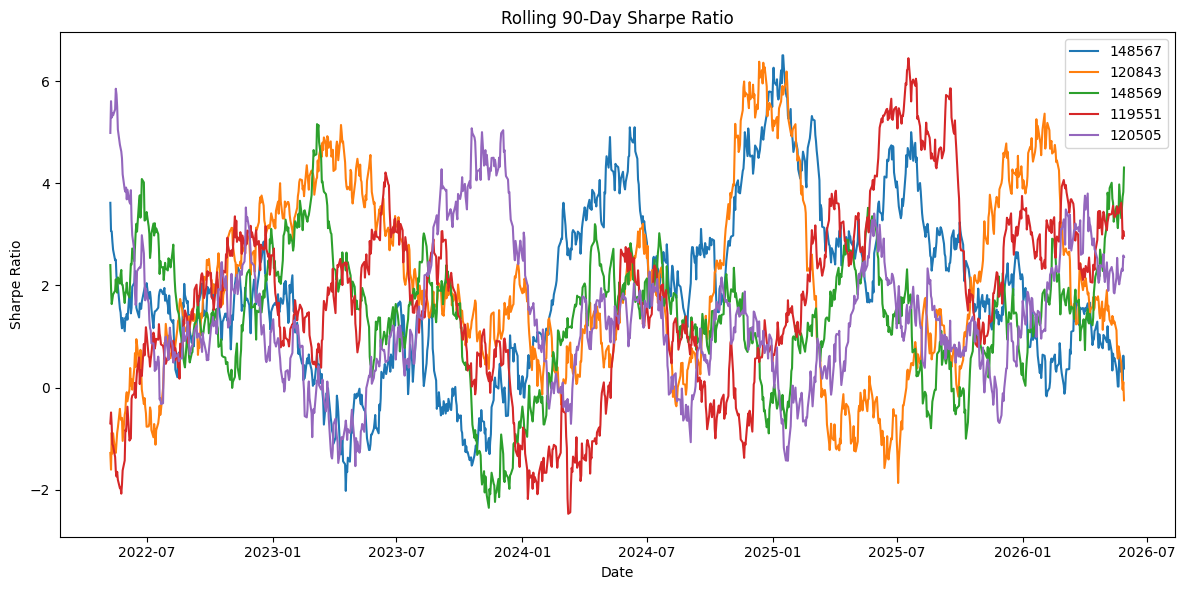

In [17]:
plt.figure(figsize=(12,6))

for fund in top_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [18]:
txn_df.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [19]:
txn_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [20]:
txn_df['transaction_date'] = pd.to_datetime(
    txn_df['transaction_date']
)

first_txn = (
    txn_df.groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date'].dt.year
)

txn_df = txn_df.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

txn_df[['investor_id', 'cohort_year']].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [21]:
txn_df['cohort_year'].value_counts().sort_index()

cohort_year
2024    32499
2025      279
Name: count, dtype: int64

In [22]:
# Average SIP Amount

sip_avg = (
    txn_df[txn_df['transaction_type'] == 'SIP']
    .groupby('cohort_year')['amount_inr']
    .mean()
)

# Total Invested

total_invested = (
    txn_df.groupby('cohort_year')['amount_inr']
    .sum()
)

# Top Fund Preference

top_fund = (
    txn_df.groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund.sort_values(
        ['cohort_year', 'count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .first()
    .reset_index()
)

# Final Cohort Summary

cohort_summary = pd.DataFrame({
    'avg_sip_amount': sip_avg,
    'total_invested': total_invested
}).reset_index()

cohort_summary = cohort_summary.merge(
    top_fund[['cohort_year', 'amfi_code']],
    on='cohort_year',
    how='left'
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,amfi_code
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


In [23]:
sip_df = txn_df[
    txn_df['transaction_type'] == 'SIP'
].copy()

sip_counts = (
    sip_df.groupby('investor_id')
    .size()
    .reset_index(name='sip_count')
)

eligible_investors = sip_counts[
    sip_counts['sip_count'] > 5
]['investor_id']

sip_df = sip_df[
    sip_df['investor_id'].isin(eligible_investors)
]

print("Eligible Investors:", len(eligible_investors))

Eligible Investors: 1362


In [24]:
sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024
8,INV003670,2024-01-01,119120,SIP,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified,2024
11,INV001023,2024-01-01,118636,SIP,4865,Gujarat,Ahmedabad,T30,36-45,Male,27.1,Net Banking,Verified,2024


In [25]:
sip_df = sip_df.sort_values(
    ['investor_id', 'transaction_date']
)

sip_df['prev_date'] = (
    sip_df.groupby('investor_id')['transaction_date']
    .shift(1)
)

sip_df['gap_days'] = (
    sip_df['transaction_date'] -
    sip_df['prev_date']
).dt.days

avg_gap = (
    sip_df.groupby('investor_id')['gap_days']
    .mean()
    .reset_index()
)

avg_gap.head()

,investor_id,gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [26]:
print(avg_gap.shape)
avg_gap.head()

(1362, 2)


,investor_id,gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [27]:
avg_gap['risk_flag'] = np.where(
    avg_gap['gap_days'] > 35,
    'At Risk',
    'Healthy'
)

avg_gap.head()

,investor_id,gap_days,risk_flag
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [28]:
avg_gap['risk_flag'].value_counts()

risk_flag
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [29]:
scorecard_df = pd.read_csv("../data/processed/fund_scorecard.csv")

print(scorecard_df.columns.tolist())
scorecard_df.head()

['amfi_code', 'cagr_1y', 'cagr_3y', 'cagr_5y', 'annual_return', 'annual_volatility', 'sharpe_ratio', 'sortino_ratio', 'alpha', 'beta', 'r_squared', 'max_drawdown', 'cagr_score', 'sharpe_score', 'sortino_score', 'alpha_score', 'drawdown_score', 'fund_score']


,amfi_code,cagr_1y,cagr_3y,cagr_5y,annual_return,annual_volatility,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,cagr_score,sharpe_score,sortino_score,alpha_score,drawdown_score,fund_score
0,100016,-2.22,1.29,2.32,3.57,14.55,-0.202,-0.351,0.0149,-0.0,0.0,-24.73,0.047166,0.271201,0.327022,0.020992,0.530589,21.89
1,100025,3.70,3.92,3.91,4.29,3.91,-0.567,-0.942,0.0178,-0.0,0.0,-4.31,0.105302,0.109982,0.181706,0.048664,0.919764,20.14
2,100033,53.23,32.44,26.07,27.21,18.94,1.094,1.829,0.1052,0.0,0.0,-16.22,0.915539,0.843640,0.863044,0.882634,0.692777,85.89
3,101206,47.92,28.97,20.44,21.46,14.57,1.027,1.800,0.0827,0.0,0.0,-11.29,0.709689,0.814046,0.855913,0.667939,0.786735,77.59
4,101207,-23.99,-4.15,6.95,10.70,25.80,0.163,0.277,0.0436,-0.0,0.0,-35.45,0.216453,0.432420,0.481436,0.294847,0.326282,35.55


In [30]:
scorecard_df['risk_grade'] = pd.qcut(
    scorecard_df['annual_volatility'],
    q=3,
    labels=['Low', 'Moderate', 'High']
)

scorecard_df[
    ['amfi_code', 'annual_volatility', 'risk_grade']
].head()

,amfi_code,annual_volatility,risk_grade
0,100016,14.55,Moderate
1,100025,3.91,Low
2,100033,18.94,High
3,101206,14.57,Moderate
4,101207,25.80,High


In [31]:
scorecard_df['risk_grade'].value_counts()

risk_grade
Low         14
High        14
Moderate    12
Name: count, dtype: int64

In [32]:
portfolio_df.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [33]:
portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [34]:
hhi_df = portfolio_df.copy()

hhi_df['weight_decimal'] = (
    hhi_df['weight_pct'] / 100
)

hhi_result = (
    hhi_df.groupby('amfi_code')['weight_decimal']
    .apply(lambda x: (x**2).sum())
    .reset_index()
)

hhi_result.columns = [
    'amfi_code',
    'HHI'
]

hhi_result.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [35]:
print(hhi_result.shape)

hhi_result.sort_values(
    'HHI',
    ascending=False
).head(10)

(34, 2)


,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


# Day 6 – Advanced Insights

### 1. Risk Analysis
Fund AMFI Code 119092 recorded the highest portfolio concentration (HHI ≈ 0.206), indicating higher sector concentration risk.

### 2. Downside Risk
CVaR values were consistently more negative than VaR values across schemes, showing larger losses during extreme downside events.

### 3. Rolling Performance
Top-performing funds maintained Rolling 90-Day Sharpe Ratios above 2.0 during recent periods, indicating strong risk-adjusted returns.

### 4. Investor Behaviour
The 2024 investor cohort accounted for the majority of investments and transaction activity compared to the 2025 cohort.

### 5. SIP Continuity
A large proportion of eligible SIP investors (1332 investors) were flagged as "At Risk" due to average gaps greater than 35 days between SIP transactions.